In [ ]:
import torch.nn.functional as F
from torch.cuda.amp import autocast
import os
import tifffile
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

In [ ]:
class BubbleDatasetGenerator:
    def __init__(self, volume_size=64, voxel_size_mm=0.2604):
        """
        Simulator of training pairs for a 3D UNet model. It creates a blurred "comet-like" input and a sharp spherical target.
        INPUT (Blurred comet-like trail) vs TARGET (Sharp sphere).
        """
        self.size = volume_size
        self.voxel_size = voxel_size_mm

        z = torch.arange(self.size, dtype=torch.float32)
        y = torch.arange(self.size, dtype=torch.float32)
        x = torch.arange(self.size, dtype=torch.float32)
        self.grid_z, self.grid_y, self.grid_x = torch.meshgrid(z, y, x, indexing='ij')

    def create_sphere(self, center_z, center_y, center_x, radius_vx):
        """Generates a binary sphere (the "bubble") at the given center and radius in voxel units."""
        dist_sq = (self.grid_z - center_z)**2 + \
                  (self.grid_y - center_y)**2 + \
                  (self.grid_x - center_x)**2
        return (dist_sq <= radius_vx**2).float()

    def get_random_unit_vector(self):
        """Generates a random unit vector in 3D space."""
        vec = torch.randn(3)
        return vec / torch.norm(vec)

    def generate_pair(self, velocity_mm_s=12.0, diameter_mm=2.06, frame_time_s=0.6, curve_strength=2.5):
        """
        Main function to generate a single training pair (blurred input and sharp target).
        - velocity_mm_s: Speed of the bubble in mm/s (how fast it moves across the volume).
        - diameter_mm: Diameter of the bubble in mm.
        - frame_time_s: Time duration of one frame in seconds (how long the bubble is visible).
        - curve_strength: How much the bubble's path curves (0 = straight line, higher values = more curve).
        """
        # calculating the radius and travel distance in voxel units
        radius_vx = (diameter_mm / 2.0) / self.voxel_size
        travel_distance_vx = (velocity_mm_s / self.voxel_size) * frame_time_s

        center = torch.tensor([self.size / 2, self.size / 2, self.size / 2])

        # generating random directions for the bubble's movement and curve
        main_dir = self.get_random_unit_vector()
        curve_dir = self.get_random_unit_vector()

        # =========================================================
        # Ground Truth: sharp sphere at the center of the volume
        # =========================================================
        target_volume = self.create_sphere(center[0], center[1], center[2], radius_vx)

        # =========================================================
        # input: blurred "comet-like" trail created by simulating the bubble's movement across the volume during the frame time
        # =========================================================
        micro_steps = 20 # Dzielimy czas klatki na 20 ujęć
        blurred_volume = torch.zeros((self.size, self.size, self.size), dtype=torch.float32)

        time_steps = torch.linspace(0.0, 1.0, micro_steps)

        # generating weights for each micro-step to simulate the motion blur (more recent positions are more visible)
        weights = torch.linspace(0.1, 1.0, micro_steps)
        total_weight = weights.sum()

        for idx, t in enumerate(time_steps):
            # calculating the position of the bubble at time t, combining linear movement and curvature
            linear_disp = (t - 0.5) * travel_distance_vx * main_dir
            curve_disp = ((t - 0.5)**2) * (travel_distance_vx * curve_strength) * curve_dir
            pos = center + linear_disp + curve_disp

            temp_sphere = self.create_sphere(pos[0], pos[1], pos[2], radius_vx)
            blurred_volume += temp_sphere * weights[idx]

        blurred_volume = blurred_volume / total_weight

        # adding some random noise to the blurred volume to make the task more realistic and challenging
        noise = torch.randn_like(blurred_volume) * 0.03
        blurred_volume = torch.clamp(blurred_volume + noise, 0.0, 1.0)

        return blurred_volume.unsqueeze(0), target_volume.unsqueeze(0)

# --- Tests ---
generator = BubbleDatasetGenerator(volume_size=64)
blurred_input, sharp_target = generator.generate_pair()

print(f"Rozmiar wejścia (Blur): {blurred_input.shape}")
print(f"Rozmiar celu (Sharp): {sharp_target.shape}")
print(f"Max wartość w celu: {sharp_target.max().item()} | Max wartość na smudze: {blurred_input.max().item():.3f}")

Rozmiar wejścia (Blur): torch.Size([1, 64, 64, 64])
Rozmiar celu (Sharp): torch.Size([1, 64, 64, 64])
Max wartość w celu: 1.0 | Max wartość na smudze: 0.399


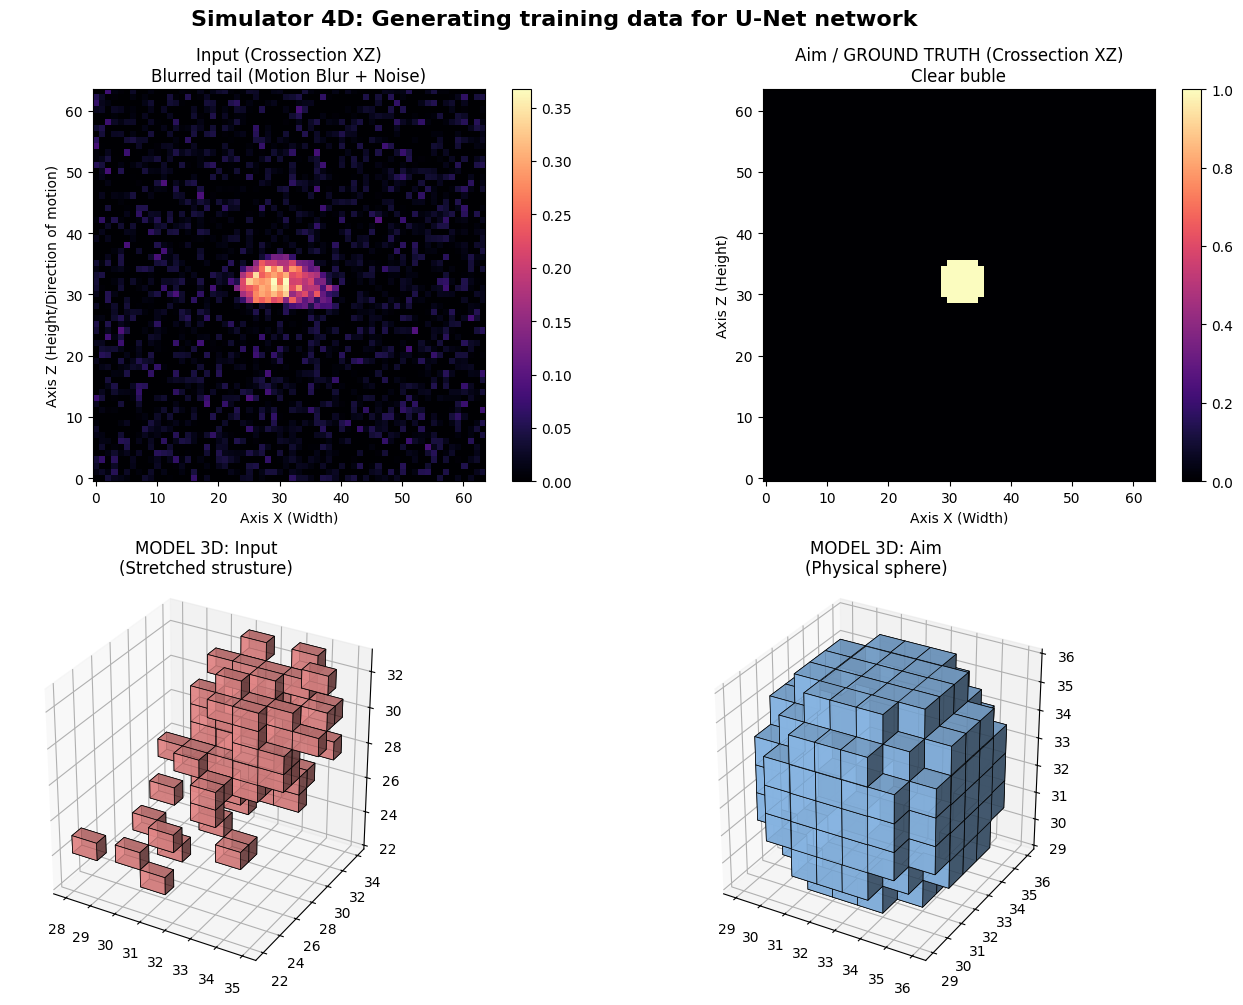

In [ ]:
import matplotlib.pyplot as plt

def visualize_bubble_pair(blurred_tensor, sharp_tensor):
    """
    Funkcja do wizualizacji pary danych: Wejście (Smuga) vs Cel (Kula).
    Tworzy wykresy 2D (przekroje) oraz 3D (woksele).
    """
    # Reshaping tensor to numpy array for visualization
    blur_np = blurred_tensor.squeeze().numpy()
    sharp_np = sharp_tensor.squeeze().numpy()

    # size of array
    size = blur_np.shape[0]
    mid = size // 2 

    fig = plt.figure(figsize=(14, 10))
    fig.suptitle("Simulator 4D: Generating training data for U-Net network", fontsize=16, fontweight='bold')

    # --- Cross-section XZ ---

    ax1 = fig.add_subplot(2, 2, 1)
    im1 = ax1.imshow(blur_np[:, mid, :], cmap='magma', origin='lower')
    ax1.set_title("Input (Crossection XZ)\nBlurred tail (Motion Blur + Noise)")
    ax1.set_xlabel("Axis X (Width)")
    ax1.set_ylabel("Axis Z (Height/Direction of motion)")
    plt.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)

    ax2 = fig.add_subplot(2, 2, 2)
    im2 = ax2.imshow(sharp_np[:, mid, :], cmap='magma', origin='lower')
    ax2.set_title("Aim / GROUND TRUTH (Crossection XZ)\nClear buble")
    ax2.set_xlabel("Axis X (Width)")
    ax2.set_ylabel("Axis Z (Height)")
    plt.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)

    # --- 3D Views ---

    # Defining thresholds for visualization (to show only the most relevant voxels and avoid clutter)
    threshold_blur = 0.3
    threshold_sharp = 0.5

    ax3 = fig.add_subplot(2, 2, 3, projection='3d')
    ax3.voxels(blur_np > threshold_blur, facecolors='#ff9999', edgecolor='k', linewidth=0.5, alpha=0.8)
    ax3.set_title("MODEL 3D: Input\n(Stretched strusture)")
    ax3.set_box_aspect([1,1,1]) # Wymusza proporcje sześcianu

    ax4 = fig.add_subplot(2, 2, 4, projection='3d')
    ax4.voxels(sharp_np > threshold_sharp, facecolors='#99ccff', edgecolor='k', linewidth=0.5, alpha=0.9)
    ax4.set_title("MODEL 3D: Aim\n(Physical sphere)")
    ax4.set_box_aspect([1,1,1])

    plt.tight_layout()
    plt.subplots_adjust(top=0.90)
    plt.savefig("bubble.png")
    plt.show()


# --- Visualization ---
# assuming blurred_input and sharp_target are the tensors generated by the BubbleDatasetGenerator
visualize_bubble_pair(blurred_input, sharp_target)

In [ ]:


# ==========================================
# 1. Architektura sieci (MODEL ARCHITECTURE)
# ==========================================

class DoubleConv3D(nn.Module):
    """Podstawowy blok budulcowy: dwie konwolucje 3D + aktywacje."""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv3d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm3d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv3d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm3d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)

class LightUNet3D(nn.Module):
    """Odchudzona wersja U-Net 3D, zoptymalizowana pod ograniczenia pamięci."""
    def __init__(self, in_channels=1, out_channels=1):
        super().__init__()

        # --- coder ---
        self.down1 = DoubleConv3D(in_channels, 16)
        self.pool1 = nn.MaxPool3d(2)

        self.down2 = DoubleConv3D(16, 32)
        self.pool2 = nn.MaxPool3d(2)

        # --- bottleneck ---
        self.bottleneck = DoubleConv3D(32, 64)

        # --- decoder ---
        self.up1 = nn.ConvTranspose3d(64, 32, kernel_size=2, stride=2)
        self.conv_up1 = DoubleConv3D(64, 32) 

        self.up2 = nn.ConvTranspose3d(32, 16, kernel_size=2, stride=2)
        self.conv_up2 = DoubleConv3D(32, 16)

        # --- FINAL CONV ---
        self.final_conv = nn.Conv3d(16, out_channels, kernel_size=1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # going down
        d1 = self.down1(x)
        p1 = self.pool1(d1)

        d2 = self.down2(p1)
        p2 = self.pool2(d2)

        # bottleneck
        b = self.bottleneck(p2)

        # incoming (with Skip Connections)
        u1 = self.up1(b)
        # concatenate the "memory" d2 with the upsampled u1 along the channel dimension (dim=1)
        u1_concat = torch.cat([d2, u1], dim=1)
        u1_out = self.conv_up1(u1_concat)

        u2 = self.up2(u1_out)
        # concatenate the "memory" d1 with the upsampled u2 along the channel dimension (dim=1)
        u2_concat = torch.cat([d1, u2], dim=1)
        u2_out = self.conv_up2(u2_concat)

        out = self.final_conv(u2_out)
        return self.sigmoid(out)


# ==========================================
# 2. training loop
# ==========================================

def train_unet():
    # inicjalization of the network, device and simulator
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Używany sprzęt do obliczeń: {device}")

    model = LightUNet3D().to(device)
    generator = BubbleDatasetGenerator(volume_size=64)

    # basic loss function for regression tasks (MSE - Mean Squared Error)
    criterion = nn.MSELoss()
    # optimalizer is our "mechanic" that updates the weights in the network (Adam is a standard choice)
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    epochs = 100        # number of training attempts
    batch_size = 2      # learning on 2 bubbles at once (to avoid filling up RAM)

    print("\nRozpoczynam trening U-Net 3D...")
    model.train() 

    for epoch in range(epochs):
        optimizer.zero_grad() 
        inputs_list = []
        targets_list = []
        for _ in range(batch_size):
            # new parameters for the bubble with a comet tail
            blurred, sharp = generator.generate_pair(velocity_mm_s=12.0, curve_strength=2.5)
            inputs_list.append(blurred)
            targets_list.append(sharp)

        # creating a batch from the list of generated pairs and sending it to the GPU
        # shape: (Batch_size, chanels, Z, Y, X)
        inputs = torch.stack(inputs_list).to(device)
        targets = torch.stack(targets_list).to(device)

        # 1. step forward - passing the blurred input through the network to get the output
        outputs = model(inputs)

        # 2. calculating the loss - how much the output differs from the ideal sphere?
        loss = criterion(outputs, targets)

        # 3. step backward (Backpropagation) - calculating the corrections
        loss.backward()

        # 4. weights update
        optimizer.step()

        # raport every 10 epochs to track the training progress
        if (epoch + 1) % 10 == 0:
            print(f"Epoka [{epoch+1}/{epochs}] | Błąd (Loss): {loss.item():.6f}")

    print("Trening zakończony! Model nauczył się odcinać ogony komety.")
    return model

# starting the training process
trained_model = train_unet()

Używany sprzęt do obliczeń: cuda

Rozpoczynam trening U-Net 3D...
Epoka [10/100] | Błąd (Loss): 0.210525
Epoka [20/100] | Błąd (Loss): 0.193315
Epoka [30/100] | Błąd (Loss): 0.176012
Epoka [40/100] | Błąd (Loss): 0.160540
Epoka [50/100] | Błąd (Loss): 0.145936
Epoka [60/100] | Błąd (Loss): 0.133281
Epoka [70/100] | Błąd (Loss): 0.122127
Epoka [80/100] | Błąd (Loss): 0.112442
Epoka [90/100] | Błąd (Loss): 0.102737
Epoka [100/100] | Błąd (Loss): 0.094399
Trening zakończony! Model nauczył się odcinać ogony komety.


In [ ]:
#-------ACCESS TO GOOGLE DRIVE IN COLAB-------
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import glob

# ==========================================
# 1. Function to process a single 3D TIFF file (with masking and normalization)
# ==========================================

def clean_real_data(trained_model, input_tiff_path, output_tiff_path, device):
    print(f"Przetwarzanie z maskowaniem: {os.path.basename(input_tiff_path)}...")
    trained_model.eval()
    real_data_np = tifffile.imread(input_tiff_path).astype(np.float32)
    Z, Y, X = real_data_np.shape

    # ==========================================
    # Mask to focus only on the liquid area (where the bubble is) and ignore the noisy borders
    # ==========================================
    y_idx, x_idx = np.indices((Y, X))
    dist_from_center = np.sqrt((x_idx - X/2)**2 + (y_idx - Y/2)**2)

    # aproximating the radius of the liquid area (for a 189x189 image, the liquid occupies roughly a circle with radius ~65 pixels)
    # If the mask cuts off your edge bubbles, increase this value (e.g., to 75).
    liquid_radius = 65
    mask_2d = dist_from_center <= liquid_radius
    mask_3d = np.broadcast_to(mask_2d, (Z, Y, X))

    # ==========================================
    # Inteligent normalization: We want to enhance the contrast of the liquid area while ignoring the noisy borders.
    # ==========================================
    liquid_pixels = real_data_np[mask_3d]
    # Using 2% and 98% to ignore extreme noise (outliers) from the tomograph
    min_val = np.percentile(liquid_pixels, 2)
    max_val = np.percentile(liquid_pixels, 98)

    normalized = (real_data_np - min_val) / (max_val - min_val + 1e-8)
    normalized = np.clip(normalized, 0.0, 1.0)

    # ==========================================
    # Inversion: We want the network to focus on 
    # the bubble as the "object" and the liquid 
    # as the "background".
    # Liquid (Background) becomes 0 (Black), 
    # Bubble becomes 1 (White)
    # ==========================================
    inverted = 1.0 - normalized

    # All pixels outside the liquid area (where the mask is False) 
    # are set to 0 (Black) to avoid confusing the network with noisy borders
    inverted[~mask_3d] = 0.0

    # Send the prepared, "inverted" image to the network
    real_tensor = torch.from_numpy(inverted).unsqueeze(0).unsqueeze(0).to(device)

    # Padding not to get dimension errors 
    # (the network reduces dimensions by a factor of 4,
    # so we need to make sure the input is divisible by 4)
    pad_z = (4 - Z % 4) % 4
    pad_y = (4 - Y % 4) % 4
    pad_x = (4 - X % 4) % 4
    real_tensor_padded = F.pad(real_tensor, (0, pad_x, 0, pad_y, 0, pad_z), mode='reflect')

    with torch.no_grad():
        with autocast():
            cleaned_tensor_padded = trained_model(real_tensor_padded)

    # cuting the padding and converting back to numpy
    cleaned_tensor = cleaned_tensor_padded[:, :, :Z, :Y, :X]
    cleaned_np = cleaned_tensor.squeeze().cpu().float().numpy()

    # save the cleaned image as a new TIFF file (with the same metadata and axes order)
    tifffile.imwrite(output_tiff_path, cleaned_np, imagej=True, metadata={'axes': 'ZYX'})

    del real_tensor, real_tensor_padded, cleaned_tensor_padded, cleaned_tensor
    torch.cuda.empty_cache()

# ===========================================================
# 2. Function to process all frames in a 
# folder (applying the cleaning function to each .tif file)
# ===========================================================
def process_all_frames(trained_model, input_folder, output_folder):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    os.makedirs(output_folder, exist_ok=True)

    # serching for all .tif files in the input folder 
    # and sorting them to maintain the correct order of frames
    surowe_pliki = sorted(glob.glob(os.path.join(input_folder, "*.tif")))

    if not surowe_pliki:
        print(f"UWAGA: Nie znaleziono żadnych plików .tif w folderze {input_folder}!")
        return

    print(f"\nZnaleziono {len(surowe_pliki)} klatek do przetworzenia.")

    for sciezka_wejsciowa in surowe_pliki:
        nazwa_pliku = os.path.basename(sciezka_wejsciowa)
        sciezka_wyjsciowa = os.path.join(output_folder, "clean_" + nazwa_pliku)
        clean_real_data(trained_model, sciezka_wejsciowa, sciezka_wyjsciowa, device)

    print("\nGotowe! Cały film 4D został naprawiony i zapisany.")


# ==========================================
# 3. Executing the processing of all frames
# in the specified input folder and saving 
# the cleaned frames to the output folder
# ==========================================

process_all_frames(
    trained_model=trained_model,
    input_folder='/content/drive/MyDrive/film4d/wyniki_4d',
    output_folder='/content/drive/MyDrive/film4d/unet'
)


Znaleziono 16 klatek do przetworzenia.
Przetwarzanie z maskowaniem: frame_000.tif...


/tmp/ipykernel_3316/3033305713.py:65: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Przetwarzanie z maskowaniem: frame_001.tif...
Przetwarzanie z maskowaniem: frame_002.tif...
Przetwarzanie z maskowaniem: frame_003.tif...
Przetwarzanie z maskowaniem: frame_004.tif...
Przetwarzanie z maskowaniem: frame_005.tif...
Przetwarzanie z maskowaniem: frame_006.tif...
Przetwarzanie z maskowaniem: frame_007.tif...
Przetwarzanie z maskowaniem: frame_008.tif...
Przetwarzanie z maskowaniem: frame_009.tif...
Przetwarzanie z maskowaniem: frame_010.tif...
Przetwarzanie z maskowaniem: frame_011.tif...
Przetwarzanie z maskowaniem: frame_012.tif...
Przetwarzanie z maskowaniem: frame_013.tif...
Przetwarzanie z maskowaniem: frame_014.tif...
Przetwarzanie z maskowaniem: frame_015.tif...

Gotowe! Cały film 4D został naprawiony i zapisany.
